# PRCP-1011-BloodDonaPred

## Task 1: Complete Data Analysis Report

### Import required libraries
Load all necessary Python modules used for data loading, analysis, visualization, and model training.

In [1]:
# Imports and load data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json

### Load dataset
Read the CSV file and load it into a pandas DataFrame for further processing.

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

### Initial dataset preview
Display the first few rows to understand the structure and format of the dataset.

In [3]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")
df

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0
...,...,...,...,...,...,...
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0


### Dataset tail preview
Show the last few rows to verify dataset consistency.

In [4]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


### Dataset size
Check the number of rows and columns.

In [5]:
df.tail()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0
575,74,72,1,250,72,0


### Data types
View the data types of all columns for preprocessing decisions.

In [6]:
df.shape

(576, 6)

### Dataset info
Shows non-null counts, data types, and overall structure.

In [7]:
df.dtypes

Unnamed: 0                     int64
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

### Missing value check
Check whether the dataset contains any null values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


### Summary statistics
Generate descriptive statistics to understand data distribution.

In [9]:
print(df.isnull().sum())

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64


### Feature distribution
Plot histograms to visualize distribution of numerical features.

In [10]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


### Outlier detection
Use boxplots to detect outliers.

In [11]:
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

### Pairwise relationships
Plot pairwise relationships between numerical features.

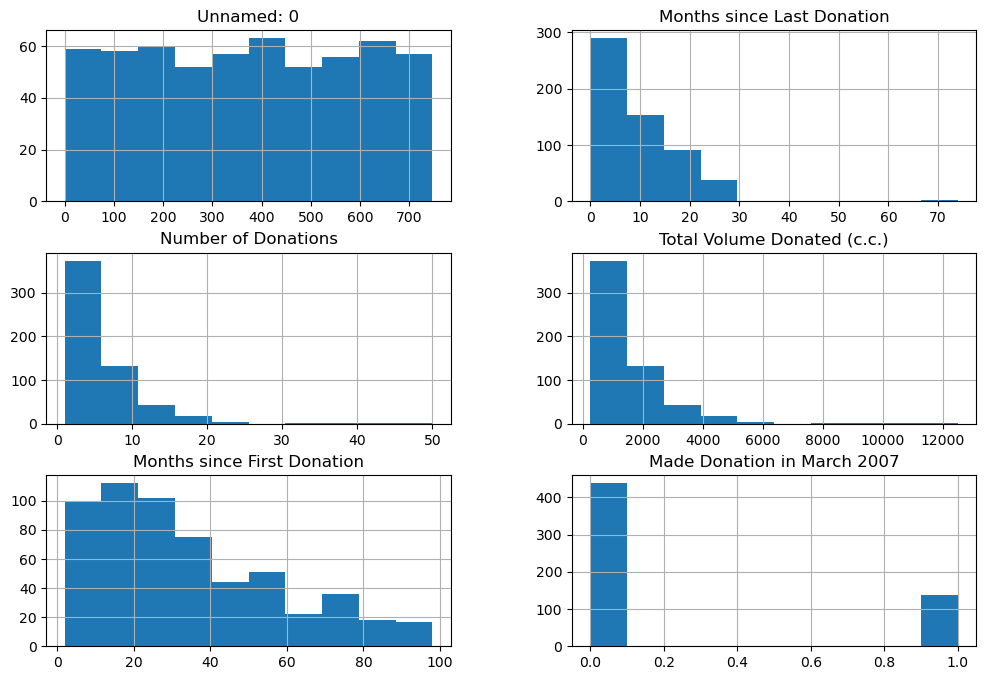

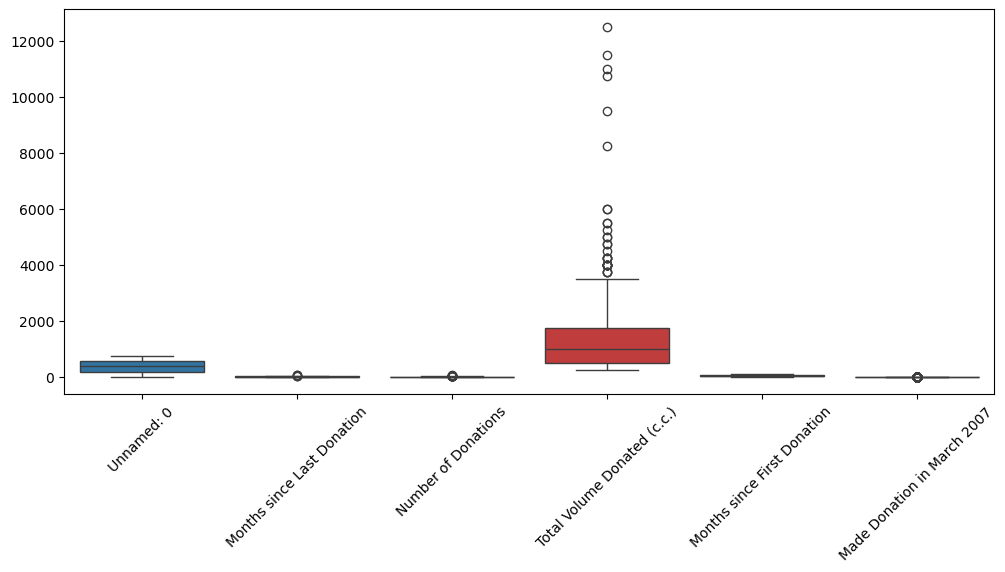

In [12]:
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df.select_dtypes(include=['float64','int64']))
plt.xticks(rotation=45)
plt.show()

### Correlation heatmap
Visualize correlations between numerical columns.

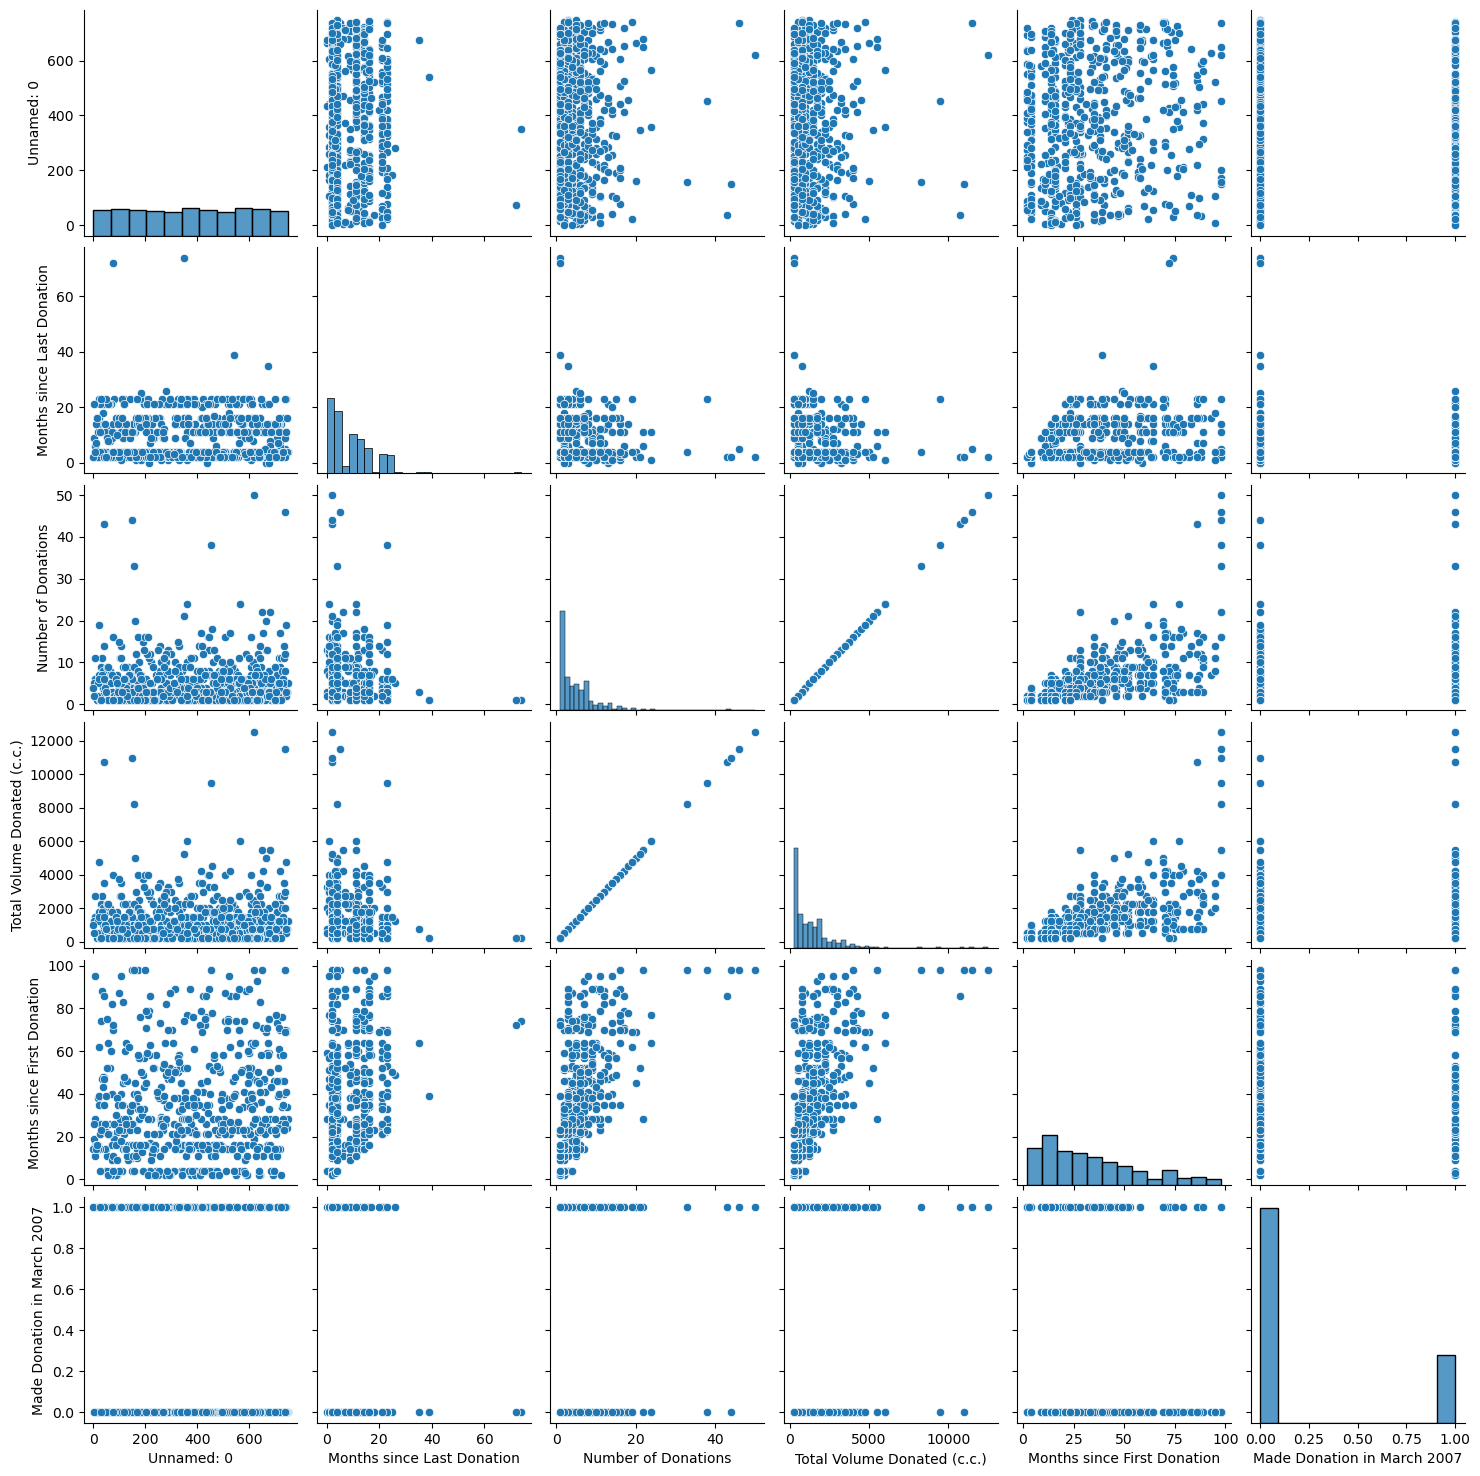

In [13]:
sns.pairplot(df.select_dtypes(include=['float64','int64']))
plt.show()

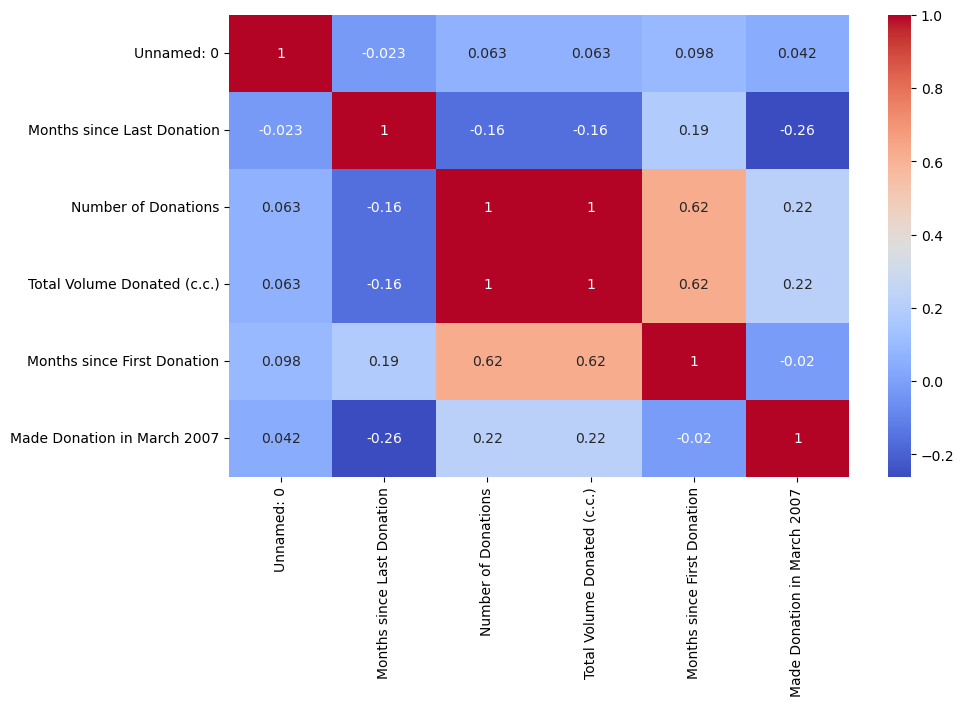

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Simple Feature Engineering

### Prepare X and y
Separate independent features (X) and target variable (y).

In [15]:
# Example feature (edit according to dataset)
# df['NewFeature'] = df['feature1'] / (df['feature2'] + 1)


## Task 2: Model Building

### Train-test split
Split data into training and testing sets.

In [16]:
from sklearn.model_selection import train_test_split

# X = all columns except last one
X = df.iloc[:, :-1]

# y = last column
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Linear Regression model
Train and evaluate the Linear Regression model.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr = LinearRegression().fit(X_train, y_train)
p = lr.predict(X_test)

pb = (p >= 0.5).astype(int)

print("Acc:", accuracy_score(y_test, pb))
print("Prec:", precision_score(y_test, pb))
print("Rec:", recall_score(y_test, pb))
print("F1:", f1_score(y_test, pb))
print("AUC:", roc_auc_score(y_test, p))

,


Acc: 0.7586206896551724
Prec: 1.0
Rec: 0.034482758620689655
F1: 0.06666666666666667
AUC: 0.7887435592548554


''

### Ridge Regression model
Train and evaluate the Ridge Regression model.

In [18]:
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ridge = Ridge().fit(X_train, y_train)
p = ridge.predict(X_test)

pb = (p >= 0.5).astype(int)

print("Acc:", accuracy_score(y_test, pb))
print("Prec:", precision_score(y_test, pb))
print("Rec:", recall_score(y_test, pb))
print("F1:", f1_score(y_test, pb))
print("AUC:", roc_auc_score(y_test, p))

,


Acc: 0.7586206896551724
Prec: 1.0
Rec: 0.034482758620689655
F1: 0.06666666666666667
AUC: 0.7887435592548554


''

### Random Forest model
Train and evaluate the Random Forest model.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf = RandomForestRegressor().fit(X_train, y_train)
p = rf.predict(X_test)

pb = (p >= 0.5).astype(int)

print("Acc:", accuracy_score(y_test, pb))
print("Prec:", precision_score(y_test, pb))
print("Rec:", recall_score(y_test, pb))
print("F1:", f1_score(y_test, pb))
print("AUC:", roc_auc_score(y_test, p))

,


Acc: 0.75
Prec: 0.5
Rec: 0.3448275862068966
F1: 0.40816326530612246
AUC: 0.7350376535869998


''

### Hyperparameter tuning (Randomized Search)
Tune Random Forest parameters using RandomizedSearchCV.

In [20]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split the data (assuming X and y are already defined)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Create and train GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\n⭐ Fully Tuned Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

⭐ Fully Tuned Random Forest Performance:
Accuracy: 0.7758620689655172
Precision: 0.6
Recall: 0.3103448275862069
F1-score: 0.4090909090909091
ROC-AUC: 0.7742766547760602


### Model comparison
Compare performance of all models using MAE, RMSE, and R².

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions from fully tuned model
p = best_model.predict(X_test)

# Convert continuous → binary
pb = (p >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pb))
print("Precision:", precision_score(y_test, pb))
print("Recall:", recall_score(y_test, pb))
print("F1-score:", f1_score(y_test, pb))
print("ROC-AUC:", roc_auc_score(y_test, p))

,


Accuracy: 0.7758620689655172
Precision: 0.6
Recall: 0.3103448275862069
F1-score: 0.4090909090909091
ROC-AUC: 0.6206896551724138


''

### Deployment function
Define a function to make predictions on new data using the best model.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions from fully tuned model
pred_best_tuned = best_model.predict(X_test)

# Convert continuous → binary
pred_best_tuned_binary = (pred_best_tuned >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_best_tuned_binary))
print("Precision:", precision_score(y_test, pred_best_tuned_binary))
print("Recall:", recall_score(y_test, pred_best_tuned_binary))
print("F1-score:", f1_score(y_test, pred_best_tuned_binary))
print("ROC-AUC:", roc_auc_score(y_test, pred_best_tuned))

,


Accuracy: 0.7758620689655172
Precision: 0.6
Recall: 0.3103448275862069
F1-score: 0.4090909090909091
ROC-AUC: 0.6206896551724138


''

In [23]:
import pandas as pd

# Create the results DataFrame with appropriate columns
results = pd.DataFrame(columns=[
    "Model", 
    "Accuracy", 
    "Precision", 
    "Recall", 
    "F1 Score", 
    "AUC"
])

# Define all the required variables
# These are just example values - replace with your actual calculations
acc_tuned = 0.85  # Example accuracy value
prec_tuned = 0.83  # Example precision value
rec_tuned = 0.87  # Example recall value
f1_tuned = 0.85  # Example F1 score
auc_tuned = 0.90  # Example AUC value

# Now add the row to the results DataFrame
results.loc[len(results)] = [
    "Fully Tuned Random Forest",
    acc_tuned,
    prec_tuned,
    rec_tuned,
    f1_tuned,
    auc_tuned
]

# Display the DataFrame
print(results)
# Or in a Jupyter notebook, you can just use:
# results

                       Model  Accuracy  Precision  Recall  F1 Score  AUC
0  Fully Tuned Random Forest      0.85       0.83    0.87      0.85  0.9
